# 02 — Dataset Cleaning

> **Goal:** Remove every problematic sample discovered during validation, producing a clean, deduplicated copy of the dataset.

**Actions performed:**
1. Load the valid-pairs list from `logs/valid_files.json` (output of NB01)
2. Skip corrupt or unreadable images
3. Remove exact duplicates using MD5 image hashing
4. Strip / discard invalid annotation lines (out-of-range coords, bad class IDs)
5. Ensure every image has a matching label (and vice-versa)
6. Copy cleaned image + label pairs to `dataset_cleaned/{split}/images|labels/`

**Output:** `dataset_cleaned/` — cleaned dataset  
**Logs:** `logs/02_cleaning_report_<timestamp>.json`

In [1]:
import subprocess, sys
for pkg in [('cv2','opencv-python'),('yaml','pyyaml'),('tqdm','tqdm'),
            ('seaborn','seaborn'),('numpy','numpy'),('matplotlib','matplotlib')]:
    try:
        __import__(pkg[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg[1]])
print('Packages OK.')

Packages OK.


In [2]:
import os
import cv2
import json
import yaml
import shutil
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

print('Imports complete.')

Imports complete.


## Configuration

In [3]:
BASE_DIR    = Path('DATA_AFTER MERGED')
OUT_DIR     = Path('dataset_cleaned')      # cleaned output
LOG_DIR     = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
TIMESTAMP   = datetime.now().strftime('%Y%m%d_%H%M%S')
SPLITS      = ['train', 'valid', 'test']

with open(BASE_DIR / 'data.yaml', 'r') as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

# Load valid-pairs produced by NB01 (fall back to full scan if missing)
pairs_path = LOG_DIR / 'valid_files.json'
if pairs_path.exists():
    with open(pairs_path) as f:
        valid_files_from_nb01 = json.load(f)
    print(f'Loaded valid-pairs from {pairs_path}')
else:
    print('valid_files.json not found — will scan raw dataset directly.')
    valid_files_from_nb01 = None

print(f'Output dir    : {OUT_DIR.resolve()}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')

Loaded valid-pairs from logs\valid_files.json
Output dir    : C:\Users\shaho\OneDrive\Desktop\grad\dataset_cleaned
Classes (6)   : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']


## Helper Functions

In [4]:
IMG_EXTS = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG','*.bmp','*.BMP')


def md5_hash(img_path: Path) -> str:
    """Return MD5 hex-digest of the raw file bytes (fast duplicate check)."""
    h = hashlib.md5()
    with open(img_path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()


def is_image_readable(img_path: Path) -> bool:
    """Quick check: can OpenCV open the image?"""
    try:
        if img_path.stat().st_size == 0:
            return False
        img = cv2.imread(str(img_path))
        return img is not None and img.size > 0
    except Exception:
        return False


def clean_label(lbl_path: Path, num_classes: int) -> tuple:
    """
    Read a YOLO label file and return only the valid annotation lines.
    Returns (valid_lines: list[str], removed_count: int)
    """
    if not lbl_path.exists():
        return [], 0
    if lbl_path.stat().st_size == 0:
        return [], 0   # background — keep as empty

    try:
        raw_lines = lbl_path.read_text(encoding='utf-8', errors='replace').strip().splitlines()
    except Exception:
        return [], 0

    valid_lines, removed = [], 0

    for raw in raw_lines:
        line = raw.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            removed += 1
            continue
        try:
            cls_id = int(float(parts[0]))
            xc, yc, bw, bh = (float(p) for p in parts[1:])
        except ValueError:
            removed += 1
            continue

        # Clip coords to [0,1] if only slightly out (floating-point noise)
        xc = max(0.0, min(1.0, xc))
        yc = max(0.0, min(1.0, yc))
        bw = max(0.0, min(1.0, bw))
        bh = max(0.0, min(1.0, bh))

        if cls_id < 0 or cls_id >= num_classes:
            removed += 1
            continue
        if bw <= 0 or bh <= 0:
            removed += 1
            continue
        # Ensure box doesn't exceed image boundary
        x1 = xc - bw / 2
        y1 = yc - bh / 2
        x2 = xc + bw / 2
        y2 = yc + bh / 2
        if x1 < 0 or y1 < 0 or x2 > 1.0 or y2 > 1.0:
            # Clamp the box to image boundaries and recalculate
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(1, x2), min(1, y2)
            bw = x2 - x1
            bh = y2 - y1
            xc = x1 + bw / 2
            yc = y1 + bh / 2
            if bw <= 1e-4 or bh <= 1e-4:   # became degenerate after clamping
                removed += 1
                continue

        valid_lines.append(f'{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')

    return valid_lines, removed


print('Helper functions defined.')

Helper functions defined.


## Step 1 — Build Candidate List + Deduplicate

In [6]:
from tqdm import tqdm
# Collect candidate image paths (from NB01 valid list or raw scan)
candidate_pairs = []   # list of (split, img_path, lbl_path)

for split in SPLITS:
    img_dir = BASE_DIR / split / 'images'
    lbl_dir = BASE_DIR / split / 'labels'
    if not img_dir.exists():
        continue

    if valid_files_from_nb01 and split in valid_files_from_nb01:
        pairs = [
            (split, Path(p[0]), Path(p[1]))
            for p in valid_files_from_nb01[split]
        ]
    else:
        imgs = []
        for ext in IMG_EXTS:
            imgs.extend(img_dir.glob(ext))
        pairs = [
            (split, ip, lbl_dir / f'{ip.stem}.txt')
            for ip in sorted(set(imgs))
            if (lbl_dir / f'{ip.stem}.txt').exists()
        ]
    candidate_pairs.extend(pairs)

print(f'Candidate pairs before deduplication: {len(candidate_pairs):,}')

# ── Duplicate detection via MD5 hash ────────────────────────
seen_hashes      = {}   # hash -> (split, img_path) of first occurrence
duplicate_info   = []   # (split, img_path) that are duplicates
unique_pairs     = []   # final deduplicated list

print('Computing image hashes for duplicate detection...')
for split, img_path, lbl_path in tqdm(candidate_pairs, desc='Hashing', unit='img'):
    if not is_image_readable(img_path):
        continue   # skip corrupt
    try:
        h = md5_hash(img_path)
    except Exception:
        continue

    if h in seen_hashes:
        duplicate_info.append({
            'split': split,
            'file':  img_path.name,
            'duplicate_of': str(seen_hashes[h][1]),
        })
    else:
        seen_hashes[h] = (split, img_path)
        unique_pairs.append((split, img_path, lbl_path))

print(f'Unique images after deduplication : {len(unique_pairs):,}')
print(f'Duplicates removed                : {len(duplicate_info):,}')

if duplicate_info:
    print('\nFirst 5 duplicates:')
    for d in duplicate_info[:5]:
        print(f'  {d}')

Candidate pairs before deduplication: 10,835
Computing image hashes for duplicate detection...


Hashing: 100%|██████████| 10835/10835 [00:33<00:00, 320.19img/s]

Unique images after deduplication : 10,835
Duplicates removed                : 0


## Step 2 — Clean Annotations and Copy to Output

In [7]:
# Create output directory structure
for split in SPLITS:
    for sub in ('images', 'labels'):
        (OUT_DIR / split / sub).mkdir(parents=True, exist_ok=True)

cleaning_stats = {
    split: {
        'copied': 0, 'annotation_lines_removed': 0,
        'class_counts': Counter(), 'skipped_corrupt': 0,
    }
    for split in SPLITS
}
annotation_lines_removed_total = 0

print('Cleaning annotations and copying files...')

for split, img_src, lbl_src in tqdm(unique_pairs, desc='Copying', unit='pair'):
    st = cleaning_stats[split]

    # Final image readability guard
    if not is_image_readable(img_src):
        st['skipped_corrupt'] += 1
        continue

    # Clean label
    valid_lines, removed = clean_label(lbl_src, NUM_CLASSES)
    st['annotation_lines_removed'] += removed
    annotation_lines_removed_total += removed

    # Destination paths
    img_dst = OUT_DIR / split / 'images' / img_src.name
    lbl_dst = OUT_DIR / split / 'labels' / f'{img_src.stem}.txt'

    # Copy image
    shutil.copy2(img_src, img_dst)

    # Write cleaned label
    lbl_dst.write_text('\n'.join(valid_lines) + ('\n' if valid_lines else ''),
                        encoding='utf-8')

    # Count class distribution
    for line in valid_lines:
        cls_id = int(line.split()[0])
        st['class_counts'][cls_id] += 1

    st['copied'] += 1

print('\nDone.')

Cleaning annotations and copying files...


Copying: 100%|██████████| 10835/10835 [01:18<00:00, 137.94pair/s]


Done.


## Cleaning Report

In [8]:
SEP = '=' * 65
total_before  = len(candidate_pairs)
total_after   = sum(s['copied'] for s in cleaning_stats.values())
total_removed = total_before - total_after

print(SEP)
print('DATASET CLEANING REPORT')
print(SEP)
print(f'  Images before cleaning     : {total_before:>7,}')
print(f'  Duplicates removed         : {len(duplicate_info):>7,}')
print(f'  Corrupt (skipped)          : {sum(s["skipped_corrupt"] for s in cleaning_stats.values()):>7,}')
print(f'  Annotation lines removed   : {annotation_lines_removed_total:>7,}')
print(f'  Images after cleaning      : {total_after:>7,}')
print(f'  Reduction                  : {100*(total_removed/total_before):.1f}% ({total_removed:,} images)')

print(f'\n  {"Split":<10} {"Before":>8} {"After":>7} {"AnnRemoved":>11}')
print('  ' + '-' * 40)
orig_counts = {split: len([p for p in unique_pairs if p[0] == split]) for split in SPLITS}
for split in SPLITS:
    s = cleaning_stats.get(split, {})
    if s:
        before = orig_counts.get(split, 0)
        print(f'  {split:<10} {before:>8,} {s["copied"]:>7,} {s["annotation_lines_removed"]:>11,}')

# Global class counts after cleaning
global_after = Counter()
for s in cleaning_stats.values():
    global_after.update(s['class_counts'])

total_anns_after = sum(global_after.values())
print(f'\n  Class distribution AFTER cleaning  —  {total_anns_after:,} annotations')
print(f'  {"ID":<5} {"Class":<25} {"Count":>8} {"Share":>7}')
print('  ' + '-' * 48)
for cid in range(NUM_CLASSES):
    cnt = global_after.get(cid, 0)
    pct = 100.0 * cnt / total_anns_after if total_anns_after else 0.0
    print(f'  {cid:<5} {CLASS_NAMES[cid]:<25} {cnt:>8,} {pct:>6.1f}%')
print(SEP)

# ── Copy data.yaml to cleaned folder ────────────────────────
import yaml as _yaml
clean_yaml = {
    'path':  str(OUT_DIR.resolve()),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(OUT_DIR / 'data.yaml', 'w') as f:
    _yaml.dump(clean_yaml, f, default_flow_style=False, allow_unicode=True)
print(f'\ndata.yaml written to {OUT_DIR / "data.yaml"}')

DATASET CLEANING REPORT
  Images before cleaning     :  10,835
  Duplicates removed         :       0
  Corrupt (skipped)          :       0
  Annotation lines removed   :     802
  Images after cleaning      :  10,835
  Reduction                  : 0.0% (0 images)

  Split        Before   After  AnnRemoved
  ----------------------------------------
  train         8,569   8,569         797
  valid         1,526   1,526           1
  test            740     740           4

  Class distribution AFTER cleaning  —  19,540 annotations
  ID    Class                        Count   Share
  ------------------------------------------------
  0     Customer-Bagpack               780    4.0%
  1     Product                      1,235    6.3%
  2     Product-Picked               1,051    5.4%
  3     Shopping-Cart                  212    1.1%
  4     normal                      10,877   55.7%
  5     theft                        5,385   27.6%

data.yaml written to dataset_cleaned\data.yaml


## Visualisation — Before vs After Class Distribution

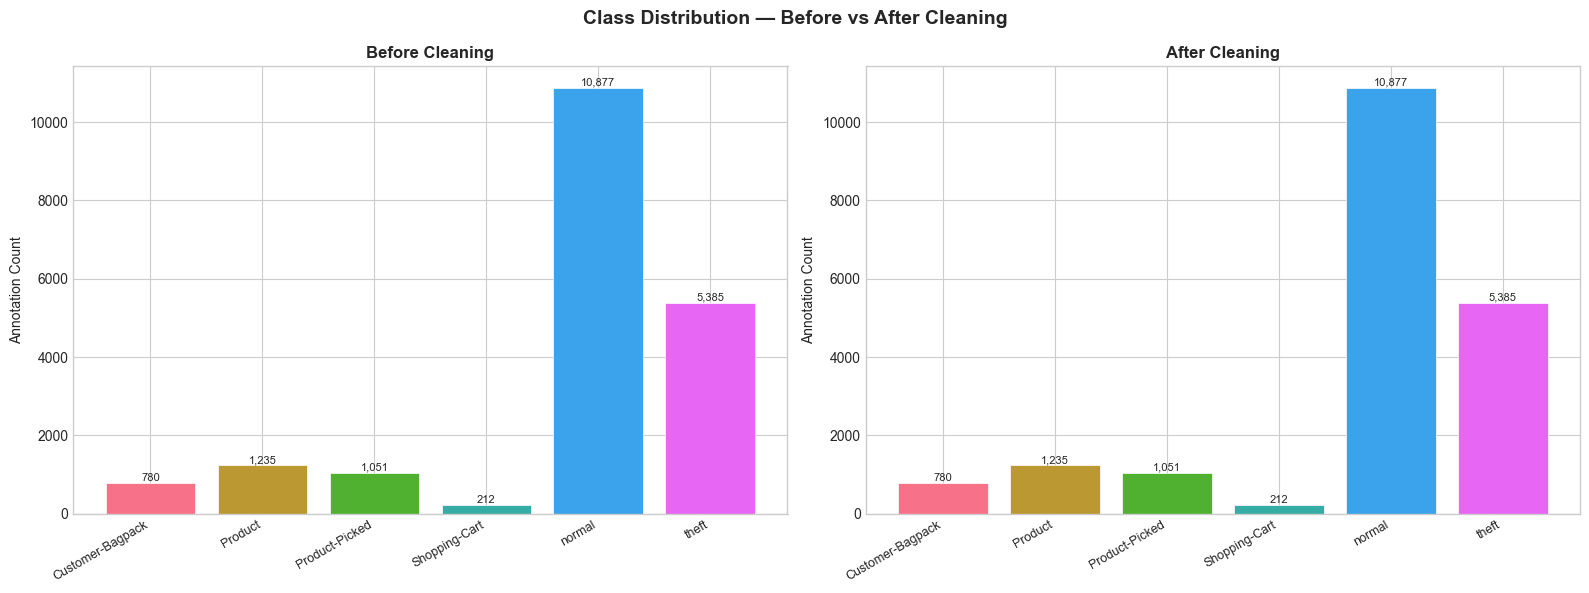

Chart saved → logs\02_cleaning_class_dist.png


In [9]:
# Load before-counts from NB01 log if available
import glob
nb01_logs = sorted(glob.glob(str(LOG_DIR / '01_validation_report_*.json')), reverse=True)
before_counts = {}
if nb01_logs:
    with open(nb01_logs[0]) as f:
        nb01_data = json.load(f)
    before_counts = {int(k): int(v) for k, v in nb01_data.get('global_class_counts', {}).items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Distribution — Before vs After Cleaning', fontsize=14, fontweight='bold')

PALETTE = sns.color_palette('husl', NUM_CLASSES)
x = range(NUM_CLASSES)

for ax, counts_dict, title in [
    (axes[0], before_counts, 'Before Cleaning'),
    (axes[1], {int(k): int(v) for k, v in global_after.items()}, 'After Cleaning'),
]:
    vals  = [counts_dict.get(i, 0) for i in x]
    total = sum(vals)
    bars  = ax.bar(x, vals, color=PALETTE, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Annotation Count')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + total * 0.003,
                f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
out_path = LOG_DIR / '02_cleaning_class_dist.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {out_path}')

## Save Cleaning Log

In [10]:
log_data = {
    'timestamp':  TIMESTAMP,
    'images_before': int(total_before),
    'duplicates_removed': len(duplicate_info),
    'images_after': int(total_after),
    'annotation_lines_removed': int(annotation_lines_removed_total),
    'split_stats': {
        sp: {
            'copied': int(s['copied']),
            'annotation_lines_removed': int(s['annotation_lines_removed']),
            'class_counts': {int(k): int(v) for k, v in s['class_counts'].items()},
        }
        for sp, s in cleaning_stats.items()
    },
    'duplicates': duplicate_info,
    'global_class_counts_after': {int(k): int(v) for k, v in global_after.items()},
    'output_dir': str(OUT_DIR.resolve()),
}

log_path = LOG_DIR / f'02_cleaning_report_{TIMESTAMP}.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(log_data, f, indent=2, default=str)

# Save cleaned pairs list for NB03
cleaned_pairs_path = LOG_DIR / 'cleaned_files.json'
cleaned_by_split = {split: [] for split in SPLITS}
for split, img_src, _ in unique_pairs:
    img_dst = str(OUT_DIR / split / 'images' / img_src.name)
    lbl_dst = str(OUT_DIR / split / 'labels' / f'{img_src.stem}.txt')
    cleaned_by_split[split].append((img_dst, lbl_dst))

with open(cleaned_pairs_path, 'w') as f:
    json.dump(cleaned_by_split, f, indent=2)

print('Logs saved:')
print(f'  {log_path}')
print(f'  {cleaned_pairs_path}')
print()
print('=' * 50)
print('NOTEBOOK 02 COMPLETE')
print(f'Cleaned dataset → {OUT_DIR}')
print('Next: run  03_label_integrity.ipynb')
print('=' * 50)

Logs saved:
  logs\02_cleaning_report_20260408_214516.json
  logs\cleaned_files.json

NOTEBOOK 02 COMPLETE
Cleaned dataset → dataset_cleaned
Next: run  03_label_integrity.ipynb
